In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully!")

Libraries imported successfully!


In [ ]:
# CELL 2: Upload Dataset

from google.colab import files

uploaded = files.upload()

filename = next(iter(uploaded))

print("Uploaded file:", filename)

Saving road_segment_risk_dataset.csv to road_segment_risk_dataset (1).csv
Uploaded file: road_segment_risk_dataset (1).csv


In [ ]:
# CELL 3: Load Dataset

df = pd.read_csv(filename)

print("Dataset loaded successfully!")
print("Dataset shape:", df.shape)

Dataset loaded successfully!
Dataset shape: (2000, 12)


In [ ]:
# CELL 4: First 5 Rows

df.head()

,location_id,traffic_volume,average_vehicle_speed,car_count,truck_count,bike_count,weather,temperature,humidity,accident_reports,signal_status,risk_level
0,R0001,4913,43.1,3062,872,682,Clear,30.6,32.6,1,Working,Medium
1,R0002,3292,60.0,1880,493,313,Cloudy,21.3,69.2,1,Working,Low
2,R0003,4359,51.6,2997,567,351,Fog,31.6,38.0,1,Not Working,Medium
3,R0004,2274,40.8,1695,219,366,Rain,33.1,62.8,2,Working,Low
4,R0005,484,50.9,336,72,70,Clear,38.6,91.9,1,Working,Low


In [ ]:
# CELL 5: Last 5 Rows

df.tail()

,location_id,traffic_volume,average_vehicle_speed,car_count,truck_count,bike_count,weather,temperature,humidity,accident_reports,signal_status,risk_level
1995,R1996,1953,52.9,1271,296,165,Fog,32.2,43.9,3,Working,Medium
1996,R1997,4410,47.5,3176,469,859,Cloudy,31.1,63.8,3,Working,Medium
1997,R1998,1803,48.0,1237,256,154,Clear,23.9,73.4,0,Working,Low
1998,R1999,1522,48.5,1110,201,282,Clear,39.4,82.0,0,Working,Low
1999,R2000,2641,50.9,1923,438,494,Clear,20.6,44.8,2,Working,Low


In [ ]:
# CELL 6: Dataset Shape

rows, columns = df.shape

print("Number of rows:", rows)
print("Number of columns:", columns)

Number of rows: 2000
Number of columns: 12


In [ ]:
# CELL 7: Column Names

print("Column names:")
for column in df.columns:
    print(column)

Column names:
location_id
traffic_volume
average_vehicle_speed
car_count
truck_count
bike_count
weather
temperature
humidity
accident_reports
signal_status
risk_level


In [ ]:
# CELL 8: Dataset Information

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   location_id            2000 non-null   object 
 1   traffic_volume         2000 non-null   int64  
 2   average_vehicle_speed  2000 non-null   float64
 3   car_count              2000 non-null   int64  
 4   truck_count            2000 non-null   int64  
 5   bike_count             2000 non-null   int64  
 6   weather                2000 non-null   object 
 7   temperature            2000 non-null   float64
 8   humidity               2000 non-null   float64
 9   accident_reports       2000 non-null   int64  
 10  signal_status          2000 non-null   object 
 11  risk_level             2000 non-null   object 
dtypes: float64(3), int64(5), object(4)
memory usage: 187.6+ KB


In [ ]:
# CELL 9: Statistical Summary

df.describe()

,traffic_volume,average_vehicle_speed,car_count,truck_count,bike_count,temperature,humidity,accident_reports
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,2610.267000,45.275850,1698.287000,339.162000,363.050500,30.038350,62.121000,1.804000
std,1399.852855,11.821194,930.262646,201.225502,219.732431,6.847187,18.626969,1.315846
min,201.000000,15.000000,126.000000,20.000000,18.000000,18.100000,30.000000,0.000000
25%,1356.500000,37.200000,873.250000,168.000000,184.750000,24.200000,45.775000,1.000000
50%,2671.000000,45.250000,1687.500000,326.500000,340.500000,29.900000,62.150000,2.000000
75%,3825.250000,53.400000,2465.000000,482.000000,514.250000,35.700000,77.900000,3.000000
max,5000.000000,85.000000,3681.000000,879.000000,978.000000,42.000000,94.900000,8.000000


In [ ]:
# CELL 10: Missing Values

missing_values = df.isnull().sum()

print("Missing values in each column:")
print(missing_values)

Missing values in each column:
location_id              0
traffic_volume           0
average_vehicle_speed    0
car_count                0
truck_count              0
bike_count               0
weather                  0
temperature              0
humidity                 0
accident_reports         0
signal_status            0
risk_level               0
dtype: int64


In [ ]:
# CELL 11: Duplicate Rows

duplicates = df.duplicated().sum()

print("Number of duplicate rows:", duplicates)

Number of duplicate rows: 0


In [ ]:
# CELL 12: Numerical Columns

numerical_columns = df.select_dtypes(
    include=["int64", "float64"]
).columns

print("Numerical columns:")
print(numerical_columns.tolist())

Numerical columns:
['traffic_volume', 'average_vehicle_speed', 'car_count', 'truck_count', 'bike_count', 'temperature', 'humidity', 'accident_reports']


In [ ]:
# CELL 13: Categorical Columns

categorical_columns = df.select_dtypes(
    include=["object"]
).columns

print("Categorical columns:")
print(categorical_columns.tolist())

Categorical columns:
['location_id', 'weather', 'signal_status', 'risk_level']


In [ ]:
# CELL 14: Unique Values

for column in df.columns:
    print("\n" + column)
    print(df[column].unique())


location_id
['R0001' 'R0002' 'R0003' ... 'R1998' 'R1999' 'R2000']

traffic_volume
[4913 3292 4359 ... 1803 1522 2641]

average_vehicle_speed
[43.1 60.  51.6 40.8 50.9 29.8 48.  27.  33.2 52.  15.  66.6 55.  22.9
 73.8 77.1 42.8 33.9 65.2 40.9 46.9 59.6 43.2 42.1 29.7 37.4 41.9 30.1
 31.2 45.4 22.8 34.5 68.3 39.4 41.  51.9 51.1 40.3 42.4 60.8 26.9 44.3
 46.6 35.7 43.6 34.1 52.6 28.9 57.7 44.1 39.6 32.9 57.4 37.2 31.  57.6
 43.9 54.8 65.8 35.  42.5 43.4 52.5 60.5 45.9 43.3 27.2 46.3 52.4 40.1
 27.5 23.3 67.3 49.9 55.5 53.3 35.4 32.3 36.2 44.7 47.  45.5 60.6 36.4
 32.  45.  24.7 46.2 55.9 42.  52.1 55.4 49.  49.6 32.5 42.2 24.3 32.7
 39.2 55.7 48.4 56.3 59.9 46.7 33.3 68.8 28.  46.4 55.2 31.1 40.  21.2
 63.1 39.3 45.8 67.8 32.2 43.  53.5 40.2 64.  53.1 47.4 36.5 60.2 53.9
 54.4 48.2 54.1 38.2 34.  44.5 37.3 41.1 44.  40.4 56.6 62.  23.7 42.9
 42.7 45.1 28.4 39.5 46.8 50.4 49.7 41.8 57.8 41.7 48.7 34.4 54.7 38.4
 45.3 47.9 38.1 52.2 47.6 27.3 21.3 58.  47.8 44.4 83.7 24.8 55.3 35.2
 49.4 

In [ ]:
# CELL 15: Number of Unique Values

print(df.nunique())

location_id              2000
traffic_volume           1633
average_vehicle_speed     492
car_count                1493
truck_count               696
bike_count                746
weather                     4
temperature               240
humidity                  612
accident_reports            9
signal_status               2
risk_level                  3
dtype: int64


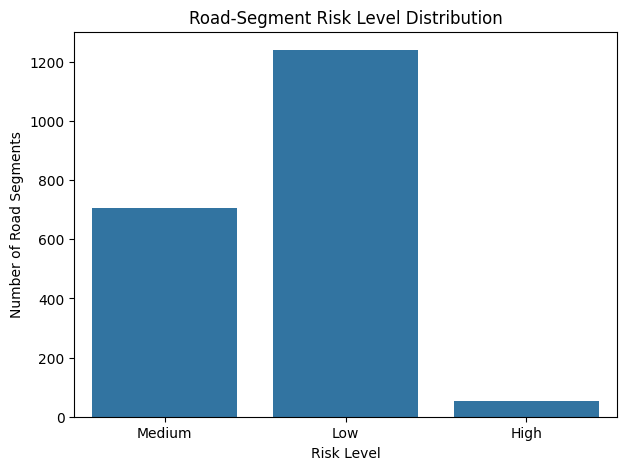

In [ ]:
# CELL 16: Risk Level Distribution

plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x="risk_level"
)

plt.title("Road-Segment Risk Level Distribution")
plt.xlabel("Risk Level")
plt.ylabel("Number of Road Segments")

plt.show()

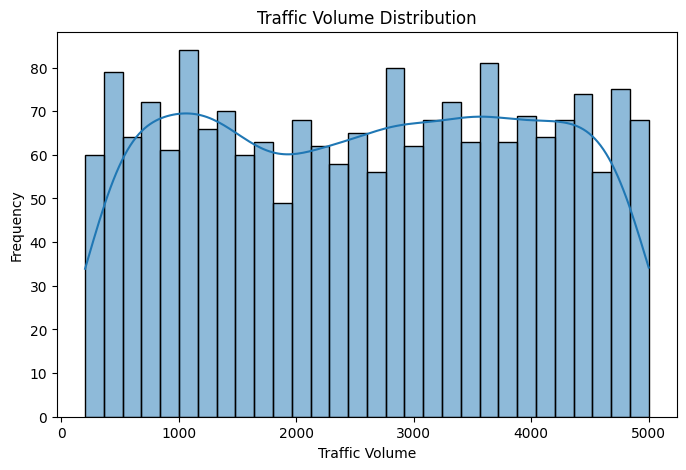

In [ ]:
# CELL 17: Traffic Volume Distribution

plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x="traffic_volume",
    bins=30,
    kde=True
)

plt.title("Traffic Volume Distribution")
plt.xlabel("Traffic Volume")
plt.ylabel("Frequency")

plt.show()

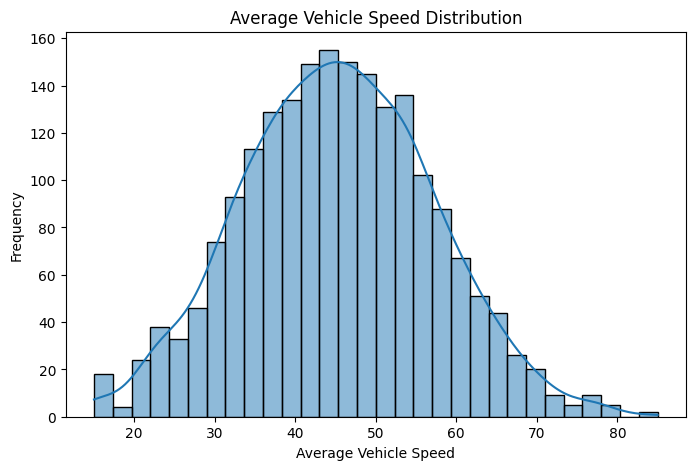

In [ ]:
# CELL 18: Average Vehicle Speed Distribution

plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x="average_vehicle_speed",
    bins=30,
    kde=True
)

plt.title("Average Vehicle Speed Distribution")
plt.xlabel("Average Vehicle Speed")
plt.ylabel("Frequency")

plt.show()

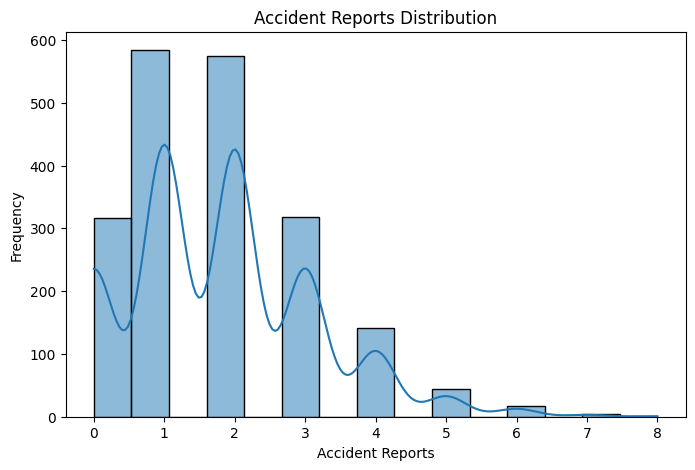

In [ ]:
# CELL 19: Accident Reports Distribution

plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x="accident_reports",
    bins=15,
    kde=True
)

plt.title("Accident Reports Distribution")
plt.xlabel("Accident Reports")
plt.ylabel("Frequency")

plt.show()

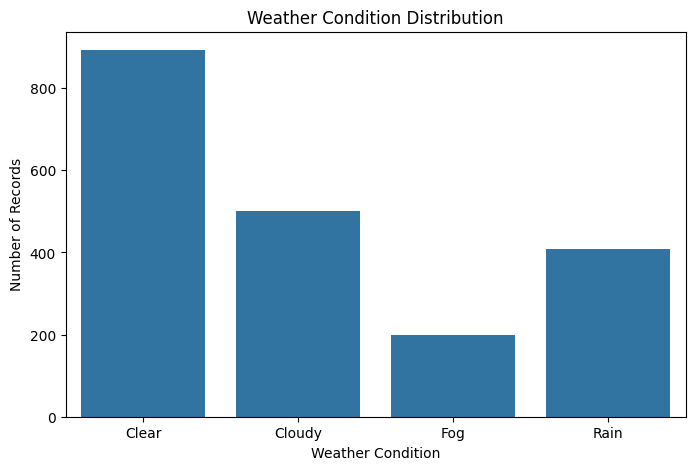

In [ ]:
# CELL 20: Weather Distribution

plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="weather"
)

plt.title("Weather Condition Distribution")
plt.xlabel("Weather Condition")
plt.ylabel("Number of Records")

plt.show()

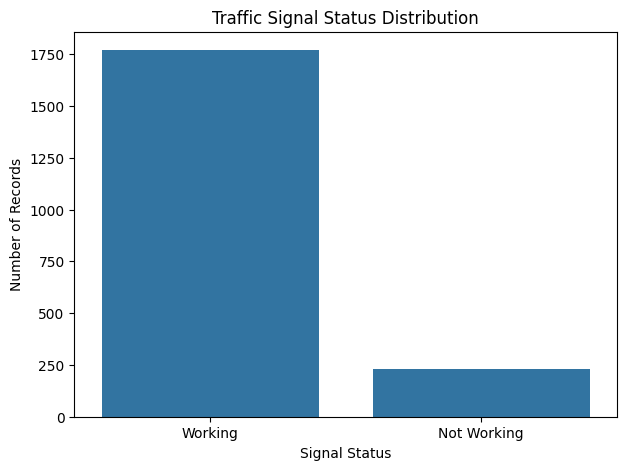

In [ ]:
# CELL 21: Traffic Signal Status

plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x="signal_status"
)

plt.title("Traffic Signal Status Distribution")
plt.xlabel("Signal Status")
plt.ylabel("Number of Records")

plt.show()

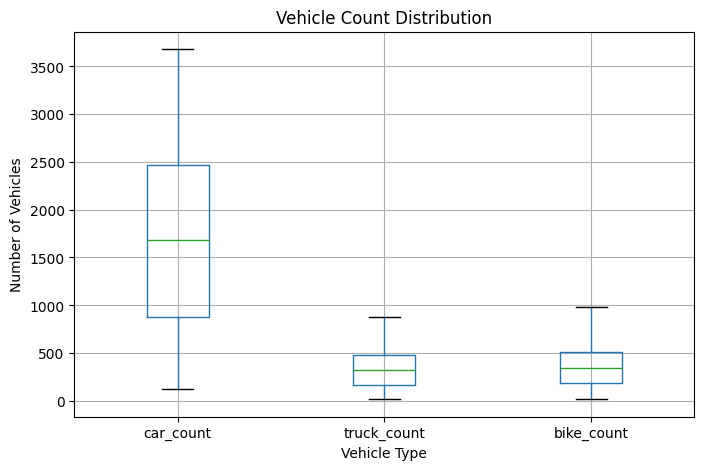

In [ ]:
# CELL 22: Vehicle Count Distribution

vehicle_columns = [
    "car_count",
    "truck_count",
    "bike_count"
]

plt.figure(figsize=(8, 5))

df[vehicle_columns].boxplot()

plt.title("Vehicle Count Distribution")
plt.xlabel("Vehicle Type")
plt.ylabel("Number of Vehicles")

plt.show()

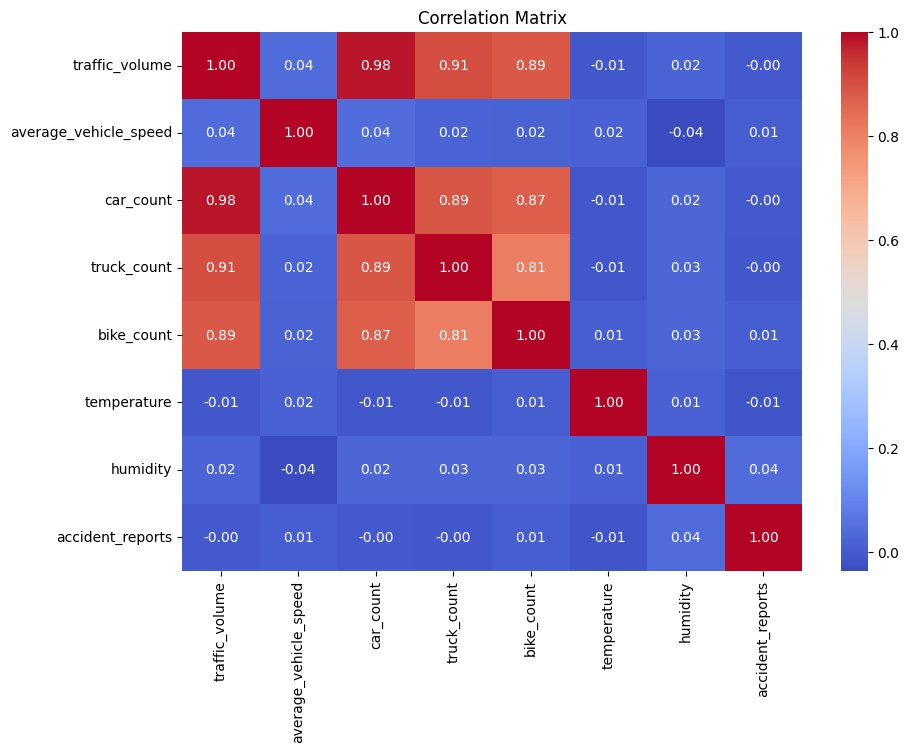

In [ ]:
# CELL 23: Correlation Matrix

numeric_df = df.select_dtypes(
    include=["int64", "float64"]
)

correlation = numeric_df.corr()

plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Correlation Matrix")

plt.show()

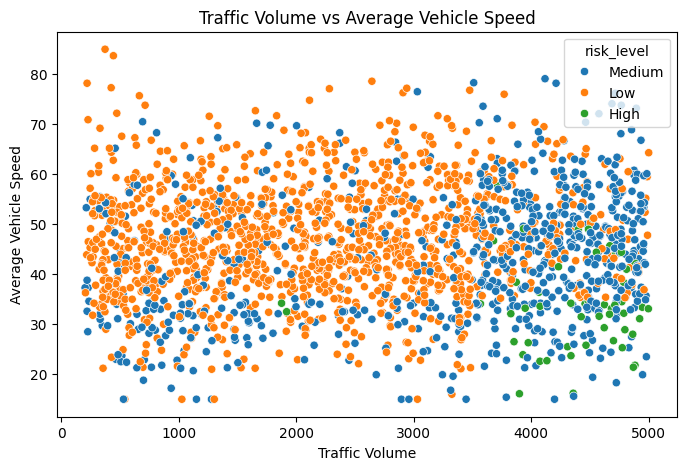

In [ ]:
# CELL 24: Traffic Volume vs Average Speed

plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="traffic_volume",
    y="average_vehicle_speed",
    hue="risk_level"
)

plt.title("Traffic Volume vs Average Vehicle Speed")
plt.xlabel("Traffic Volume")
plt.ylabel("Average Vehicle Speed")

plt.show()

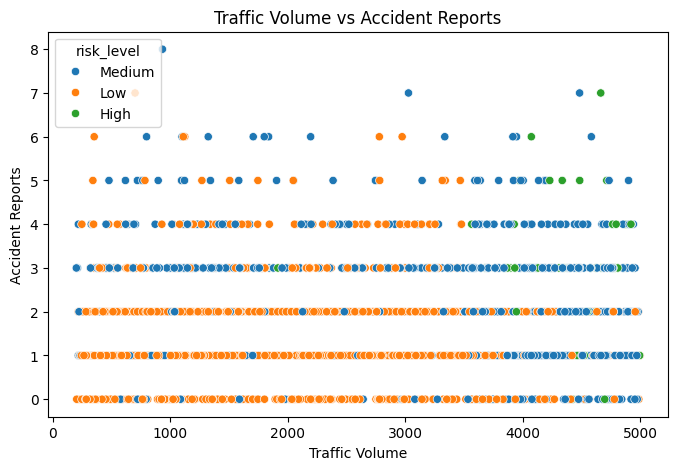

In [ ]:
# CELL 25: Traffic Volume vs Accident Reports

plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="traffic_volume",
    y="accident_reports",
    hue="risk_level"
)

plt.title("Traffic Volume vs Accident Reports")
plt.xlabel("Traffic Volume")
plt.ylabel("Accident Reports")

plt.show()

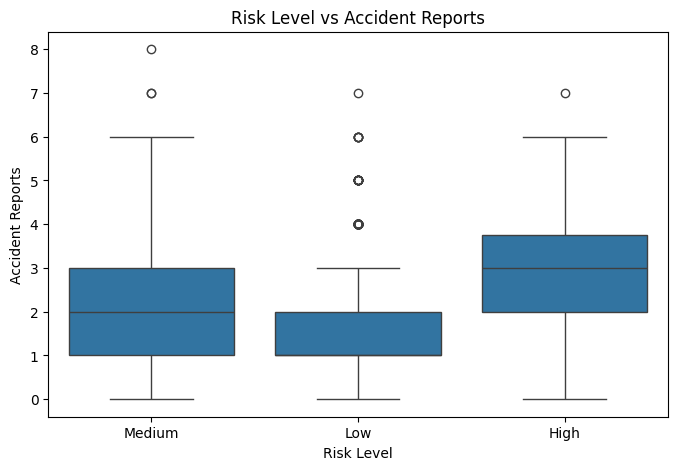

In [ ]:
# CELL 26: Risk Level vs Accident Reports

plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="risk_level",
    y="accident_reports"
)

plt.title("Risk Level vs Accident Reports")
plt.xlabel("Risk Level")
plt.ylabel("Accident Reports")

plt.show()

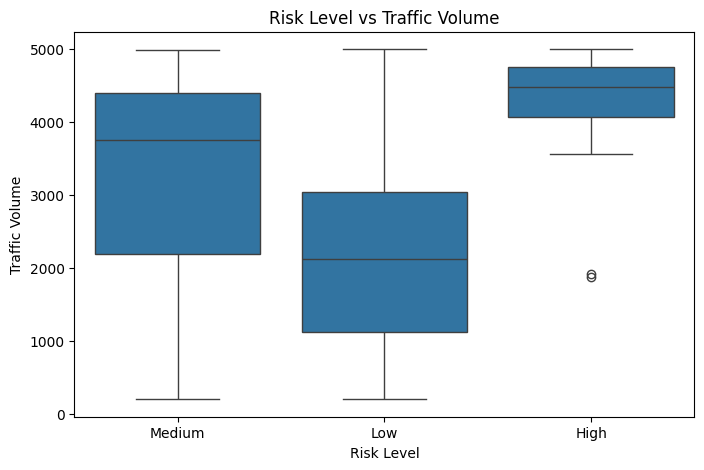

In [ ]:
# CELL 27: Risk Level vs Traffic Volume

plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="risk_level",
    y="traffic_volume"
)

plt.title("Risk Level vs Traffic Volume")
plt.xlabel("Risk Level")
plt.ylabel("Traffic Volume")

plt.show()

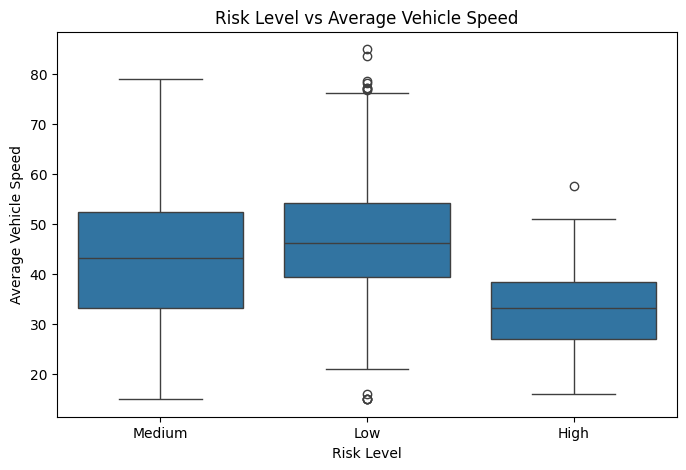

In [ ]:
# CELL 28: Risk Level vs Average Vehicle Speed

plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="risk_level",
    y="average_vehicle_speed"
)

plt.title("Risk Level vs Average Vehicle Speed")
plt.xlabel("Risk Level")
plt.ylabel("Average Vehicle Speed")

plt.show()


In [ ]:
# CELL 29: Final EDA Summary

print("==========================================")
print("ROAD-SEGMENT RISK CLASSIFICATION")
print("EDA COMPLETED SUCCESSFULLY")
print("==========================================")

print("\nDataset Shape:", df.shape)
print("Missing Values:", df.isnull().sum().sum())
print("Duplicate Rows:", df.duplicated().sum())

print("\nRisk Level Counts:")
print(df["risk_level"].value_counts())

ROAD-SEGMENT RISK CLASSIFICATION
EDA COMPLETED SUCCESSFULLY

Dataset Shape: (2000, 12)
Missing Values: 0
Duplicate Rows: 0

Risk Level Counts:
risk_level
Low       1240
Medium     706
High        54
Name: count, dtype: int64
